# M19 · RAG & query understanding — ✍️ Toy Examples, Step by Tiny Step

**Companion to lesson M19. Written for someone new to ML.**

This notebook has two parts that belong together:

- **Part A · RAG (Retrieval-Augmented Generation):** retrieve trusted text, add it to the prompt, then generate from that evidence.
- **Part B · Query understanding:** turn messy natural language into `{intent, slots}`, ground values against trusted data, score confidence, and route safely.

Everything is tiny and offline: no network, no downloads, and no real LLM. We use TF-IDF vectors, rules,
and simulated answers so every number is visible.

## Step 0 · Setup

Import only Colab-preinstalled libraries plus Python's standard library. Fix the **seed** so outputs are
reproducible, set one figure size, and define `log(label, value)` for readable printouts.

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4)

def log(label, value):
    print(f"[{label}] {value}")

log("setup", "ready — NumPy + Pandas + scikit-learn + Matplotlib imported; seed fixed to 0")

[setup] ready — NumPy + Pandas + scikit-learn + Matplotlib imported; seed fixed to 0


---
# Part A · RAG: retrieve grounded context, then answer

## Part A Step 1 · Toy example — the problem RAG solves

A plain language model can miss **fresh facts**, **private facts**, or tiny facts from your own docs. If it
answers anyway, it may **hallucinate**: make up a confident-sounding answer.

**RAG** means **Retrieval-Augmented Generation**:
1. **Retrieve** relevant text from a trusted corpus (a corpus is a collection of documents).
2. **Augment** the prompt by adding that text.
3. **Generate** an answer using only the retrieved evidence.

**Good for:** answering from known docs, private knowledge bases, and facts that change over time.  
**Watch out for:** RAG cannot fix missing or wrong retrieved context.

RAG pipeline in order:
  1. corpus
  2. chunk
  3. embed
  4. index
  5. query
  6. embed query
  7. retrieve top-k
  8. augment prompt
  9. generate
Key idea: generation is only allowed to use the retrieved context.


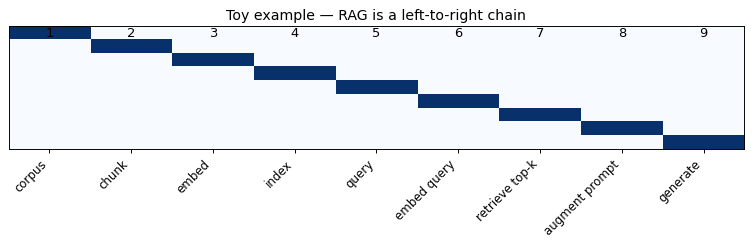

In [5]:
a_pipeline_steps = [
    "corpus", "chunk", "embed", "index",
    "query", "embed query", "retrieve top-k", "augment prompt", "generate"
]

print("RAG pipeline in order:")

for a_step_no, a_step_name in enumerate(a_pipeline_steps, 1):
    print(f"  {a_step_no}. {a_step_name}")

print("Key idea: generation is only allowed to use the retrieved context.")

a_pipeline_picture = np.eye(len(a_pipeline_steps))
plt.figure(figsize=(9, 3))
plt.imshow(a_pipeline_picture, cmap="Blues", aspect="auto")
plt.xticks(range(len(a_pipeline_steps)), a_pipeline_steps, rotation=45, ha="right")
plt.yticks([])
for a_step_no, a_step_name in enumerate(a_pipeline_steps):
    plt.text(a_step_no, 0, str(a_step_no + 1), ha="center", va="center", fontsize=11)
plt.title("Toy example — RAG is a left-to-right chain")
plt.tight_layout()
plt.show()

▶ What you'll see: a simple left-to-right map from documents to a grounded answer.

## Part A Step 2 · Toy example — corpus → chunks

A **chunk** is a smaller piece of a document that we search over. We use a tiny fake company FAQ so every
fact is visible.

**Good for:** small chunks make retrieval focused.  
**Watch out for:** too big = noisy context; too small = lost meaning.

Documents: 7
Chunks: 9
chunk_id doc_id           title                                                                             text
     C00     D1 Vacation policy                          Full-time employees receive 15 vacation days each year.
     C01     D1 Vacation policy                                   Interns receive 5 vacation days during summer.
     C02     D2  Password reset                                    Reset your password from the security portal.
     C03     D2  Password reset                                           A reset link expires after 20 minutes.
     C04     D3   Lunch benefit      The company cafe gives every employee a 12 dollar lunch credit on weekdays.
     C05     D4     Remote work       Team members may work remotely on Monday and Friday with manager approval.
     C06     D5     Office pets Dogs are allowed in the office on Friday if they are registered with facilities.
     C07     D6  Data retention                    Customer analytics log

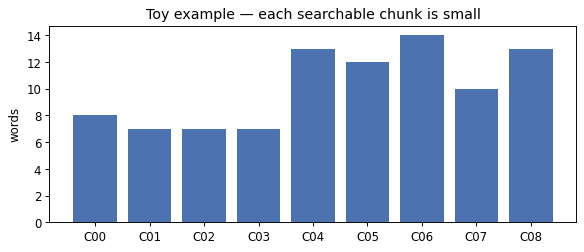

In [8]:
a_docs = [
    {"doc_id": "D1", "title": "Vacation policy",
     "text": "Full-time employees receive 15 vacation days each year. Interns receive 5 vacation days during summer."},
    {"doc_id": "D2", "title": "Password reset",
     "text": "Reset your password from the security portal. A reset link expires after 20 minutes."},
    {"doc_id": "D3", "title": "Lunch benefit",
     "text": "The company cafe gives every employee a 12 dollar lunch credit on weekdays."},
    {"doc_id": "D4", "title": "Remote work",
     "text": "Team members may work remotely on Monday and Friday with manager approval."},
    {"doc_id": "D5", "title": "Office pets",
     "text": "Dogs are allowed in the office on Friday if they are registered with facilities."},
    {"doc_id": "D6", "title": "Data retention",
     "text": "Customer analytics logs are kept for 30 days before deletion."},
    {"doc_id": "D7", "title": "Support hours",
     "text": "IT support answers urgent tickets from 8 AM to 6 PM Eastern time."},
]

def a_sentence_chunks(a_text):
    a_pieces = [a_piece.strip() for a_piece in a_text.split(".") if a_piece.strip()]
    return [a_piece + "." for a_piece in a_pieces]

a_chunks = []
for a_doc in a_docs:
    for a_sent_no, a_sent in enumerate(a_sentence_chunks(a_doc["text"])):
        a_chunks.append({
            "chunk_id": f"C{len(a_chunks):02d}",
            "doc_id": a_doc["doc_id"],
            "title": a_doc["title"],
            "sentence": a_sent_no,
            "text": a_sent,
        })

a_chunk_df = pd.DataFrame(a_chunks)

print("Documents:", len(a_docs))
print("Chunks:", len(a_chunks))
print(a_chunk_df[["chunk_id", "doc_id", "title", "text"]].to_string(index=False))

a_chunk_lengths = [len(a_chunk["text"].split()) for a_chunk in a_chunks]

print("Chunk lengths in words:", a_chunk_lengths)

assert len(a_chunks) == 9
assert a_chunks[1]["text"] == "Interns receive 5 vacation days during summer."

plt.figure(figsize=(8, 3))
plt.bar([a_chunk["chunk_id"] for a_chunk in a_chunks], a_chunk_lengths, color="#4C72B0")
plt.ylabel("words")
plt.title("Toy example — each searchable chunk is small")
plt.show()

▶ What you'll see: 7 documents become 9 short searchable chunks.

## Part A Step 3 · Toy example — chunking tradeoffs

Chunk size is a design choice. We print the same sentence chopped three ways so you can see the tradeoff.

**Good for:** deciding what the retriever is allowed to return.  
**Watch out for:** chunking is not a law; evaluate it with real questions.

Original text: Interns receive 5 vacation days during summer and managers approve Monday remote work.
Too big chunk: ['Interns receive 5 vacation days during summer and managers approve Monday remote work.']
Just-right chunks: ['Interns receive 5 vacation days during summer.', 'and managers approve Monday remote work.']
Too small chunks: ['Interns receive', '5 vacation', 'days during', 'summer and', 'managers approve', 'Monday remote', 'work']
Noise scores (lower is better): {'too big': 8, 'just right': 3, 'too small': 1}
Meaning scores (higher is better): {'too big': 8, 'just right': 8, 'too small': 3}


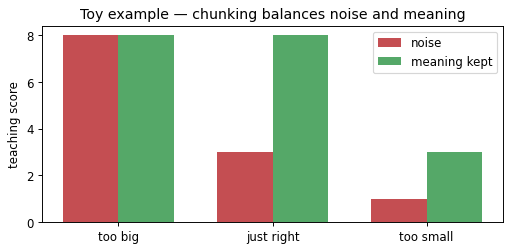

In [11]:
a_tradeoff_text = "Interns receive 5 vacation days during summer and managers approve Monday remote work."
a_tradeoff_words = a_tradeoff_text.replace(".", "").split()

a_too_big = [a_tradeoff_text]
a_just_right = [" ".join(a_tradeoff_words[:7]) + ".", " ".join(a_tradeoff_words[7:]) + "."]
a_too_small = [" ".join(a_tradeoff_words[a_i:a_i+2]) for a_i in range(0, len(a_tradeoff_words), 2)]

print("Original text:", a_tradeoff_text)
print("Too big chunk:", a_too_big)
print("Just-right chunks:", a_just_right)
print("Too small chunks:", a_too_small)

a_noise_score = [8, 3, 1]       # teaching score: more unrelated words mixed in
a_meaning_score = [8, 8, 3]     # teaching score: enough words to preserve meaning
a_chunk_labels = ["too big", "just right", "too small"]

print("Noise scores (lower is better):", dict(zip(a_chunk_labels, a_noise_score)))
print("Meaning scores (higher is better):", dict(zip(a_chunk_labels, a_meaning_score)))

assert a_noise_score[1] < a_noise_score[0]
assert a_meaning_score[1] > a_meaning_score[2]

a_x = np.arange(len(a_chunk_labels))
plt.figure(figsize=(7, 3))
plt.bar(a_x - 0.18, a_noise_score, width=0.36, label="noise", color="#C44E52")
plt.bar(a_x + 0.18, a_meaning_score, width=0.36, label="meaning kept", color="#55A868")
plt.xticks(a_x, a_chunk_labels)
plt.ylabel("teaching score")
plt.title("Toy example — chunking balances noise and meaning")
plt.legend()
plt.show()

▶ What you'll see: the middle option keeps meaning without mixing too many facts.

## Part A Step 4 · Toy example — embed chunks with TF-IDF

An **embedding** is a vector: a list of numbers that represents text. Real RAG systems often use neural
encoders. Here, **TF-IDF** stands in for an encoder because it is offline and transparent.

The **index** is the chunk-by-term matrix we search.

**Good for:** seeing exactly which words drive retrieval.  
**Watch out for:** TF-IDF is mostly lexical; synonyms can be hard.

Number of chunks: 9
Vocabulary size: 99
Index shape = rows(chunks) x columns(terms): (9, 99)
First 20 vocabulary terms: ['12', '12 dollar', '15', '15 vacation', '20', '20 minutes', '30', '30 days', 'allowed', 'allowed office', 'analytics', 'analytics logs', 'answers', 'answers urgent', 'approval', 'cafe', 'cafe gives', 'company', 'company cafe', 'credit']
Non-zero weights in C01: 9
Terms shown in heatmap: ['receive vacation', 'security', 'reset password', 'portal', 'password security', 'password', 'security portal', 'friday', 'time', 'receive', 'vacation', 'vacation days', 'reset', 'days']


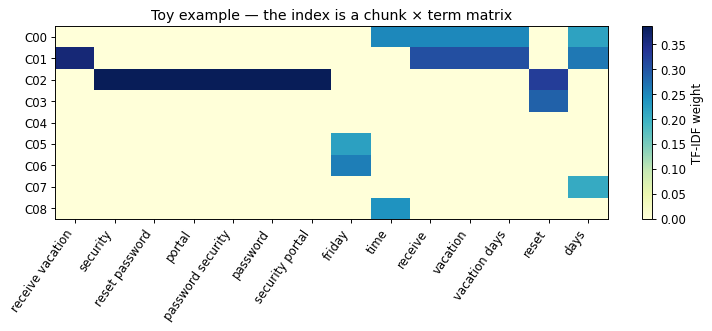

In [14]:
a_chunk_texts = [a_chunk["text"] for a_chunk in a_chunks]
a_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), lowercase=True)
a_index = a_vectorizer.fit_transform(a_chunk_texts).toarray()
a_terms = np.array(a_vectorizer.get_feature_names_out())

print("Number of chunks:", len(a_chunk_texts))
print("Vocabulary size:", len(a_terms))
print("Index shape = rows(chunks) x columns(terms):", a_index.shape)
print("First 20 vocabulary terms:", a_terms[:20].tolist())
print("Non-zero weights in C01:", int((a_index[1] > 0).sum()))

assert a_index.shape[0] == len(a_chunks)
assert a_index.shape[1] == len(a_terms)

a_top_cols = np.argsort(a_index.sum(axis=0))[-14:]
a_heat = a_index[:, a_top_cols]

print("Terms shown in heatmap:", a_terms[a_top_cols].tolist())

plt.figure(figsize=(9, 4))
plt.imshow(a_heat, cmap="YlGnBu", aspect="auto")
plt.xticks(range(len(a_top_cols)), a_terms[a_top_cols], rotation=55, ha="right")
plt.yticks(range(len(a_chunks)), [a_chunk["chunk_id"] for a_chunk in a_chunks])
plt.colorbar(label="TF-IDF weight")
plt.title("Toy example — the index is a chunk × term matrix")
plt.tight_layout()
plt.show()

▶ What you'll see: each row is a chunk vector; each column is a term weight.

## Part A Step 5 · Toy example — inspect one vector

This is what "turn text into numbers" looks like. We print the non-zero coordinates for the intern
vacation chunk.

Chunk inspected: C01 Interns receive 5 vacation days during summer.
Non-zero TF-IDF weights:
  days summer        -> 0.361
  interns            -> 0.361
  interns receive    -> 0.361
  receive vacation   -> 0.361
  summer             -> 0.361
  receive            -> 0.305
  vacation           -> 0.305
  vacation days      -> 0.305
  days               -> 0.265


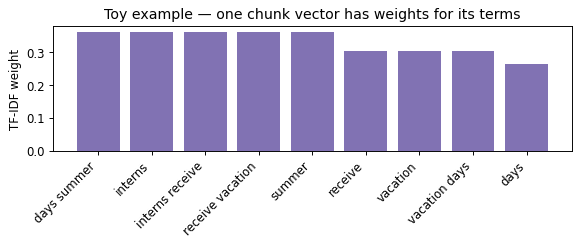

In [17]:
a_inspect_id = "C01"
a_inspect_i = [a_i for a_i, a_chunk in enumerate(a_chunks) if a_chunk["chunk_id"] == a_inspect_id][0]
a_inspect_weights = a_index[a_inspect_i]
a_nonzero = [(a_terms[a_i], float(a_inspect_weights[a_i])) for a_i in np.where(a_inspect_weights > 0)[0]]
a_nonzero = sorted(a_nonzero, key=lambda a_pair: -a_pair[1])

print("Chunk inspected:", a_inspect_id, a_chunks[a_inspect_i]["text"])
print("Non-zero TF-IDF weights:")

for a_term, a_weight in a_nonzero:
    print(f"  {a_term:18s} -> {a_weight:.3f}")
assert any(a_term == "interns" for a_term, _ in a_nonzero)
assert any(a_term == "vacation days" for a_term, _ in a_nonzero)

plt.figure(figsize=(7, 3))
plt.bar([a_term for a_term, _ in a_nonzero], [a_weight for _, a_weight in a_nonzero], color="#8172B3")
plt.xticks(rotation=45, ha="right")
plt.ylabel("TF-IDF weight")
plt.title("Toy example — one chunk vector has weights for its terms")
plt.tight_layout()
plt.show()

▶ What you'll see: terms like `interns` and `vacation days` get visible non-zero weights.

## Part A Step 6 · Toy example — cosine similarity math

Cosine similarity measures whether two vectors point in the same direction:

$\text{cosine}(q, c) = \frac{q \cdot c}{\|q\|\,\|c\|}$

With TF-IDF vectors, scores are usually between 0 and 1 because word weights are non-negative.

Toy query vector: [1.0, 1.0, 0.0]
Close chunk vector: [1.0, 0.8, 0.0] dot= 1.8 norm product= 1.811 cosine= 0.994
Far chunk vector: [0.0, 0.1, 1.0] dot= 0.1 norm product= 1.421 cosine= 0.07


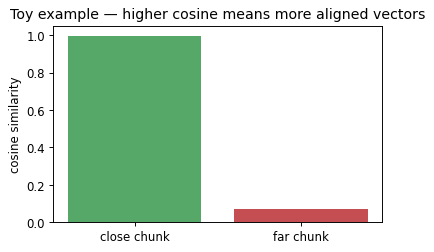

In [20]:
a_q_toy = np.array([1.0, 1.0, 0.0])
a_close_chunk_toy = np.array([1.0, 0.8, 0.0])
a_far_chunk_toy = np.array([0.0, 0.1, 1.0])

def a_cosine_pair(a_left, a_right):
    a_dot = float(a_left @ a_right)
    a_norms = float(np.linalg.norm(a_left) * np.linalg.norm(a_right))
    return a_dot / (a_norms + 1e-12), a_dot, a_norms

a_close_cos, a_close_dot, a_close_norms = a_cosine_pair(a_q_toy, a_close_chunk_toy)
a_far_cos, a_far_dot, a_far_norms = a_cosine_pair(a_q_toy, a_far_chunk_toy)

print("Toy query vector:", a_q_toy.tolist())
print("Close chunk vector:", a_close_chunk_toy.tolist(), "dot=", round(a_close_dot, 3), "norm product=", round(a_close_norms, 3), "cosine=", round(a_close_cos, 3))
print("Far chunk vector:", a_far_chunk_toy.tolist(), "dot=", round(a_far_dot, 3), "norm product=", round(a_far_norms, 3), "cosine=", round(a_far_cos, 3))

assert a_close_cos > a_far_cos

plt.figure(figsize=(5, 3))
plt.bar(["close chunk", "far chunk"], [a_close_cos, a_far_cos], color=["#55A868", "#C44E52"])
plt.ylabel("cosine similarity")
plt.ylim(0, 1.05)
plt.title("Toy example — higher cosine means more aligned vectors")
plt.show()

▶ What you'll see: the closer vector has a much higher cosine score.

## Part A Step 7 · Toy example — query → retrieve top-k

Now the user asks a question. We embed the query with the **same vectorizer**, compute cosine similarity
to every chunk, sort from highest to lowest, and keep top-k.

**Good for:** giving the generator a short evidence list.  
**Watch out for:** chunks and queries must live in the same vector space.

Query: How many vacation days do interns receive?
Query terms that exist in the vocabulary:
  days               -> 0.339
  interns            -> 0.462
  interns receive    -> 0.462
  receive            -> 0.390
  vacation           -> 0.390
  vacation days      -> 0.390
Cosine similarity to every chunk:
  C00 (Vacation policy) sim=0.367 text=Full-time employees receive 15 vacation days each year.
  C01 (Vacation policy) sim=0.781 text=Interns receive 5 vacation days during summer.
  C02 (Password reset ) sim=0.000 text=Reset your password from the security portal.
  C03 (Password reset ) sim=0.000 text=A reset link expires after 20 minutes.
  C04 (Lunch benefit  ) sim=0.000 text=The company cafe gives every employee a 12 dollar lunch credit on weekdays.
  C05 (Remote work    ) sim=0.000 text=Team members may work remotely on Monday and Friday with manager approval.
  C06 (Office pets    ) sim=0.000 text=Dogs are allowed in the office on Friday if they are registered with facilities.
 

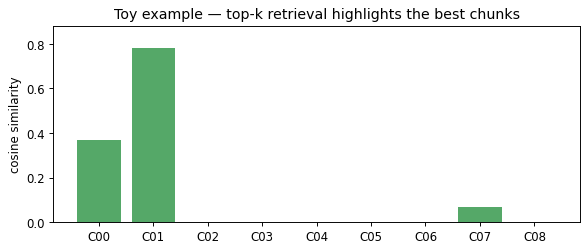

In [23]:
def a_cosine_scores(a_query_text):
    a_q_vec = a_vectorizer.transform([a_query_text]).toarray()[0]
    a_q_norm = np.linalg.norm(a_q_vec)
    a_index_norms = np.linalg.norm(a_index, axis=1)
    if a_q_norm == 0:
        a_sims_local = np.zeros(len(a_index))
    else:
        a_sims_local = (a_index @ a_q_vec) / (a_index_norms * a_q_norm + 1e-12)
    return a_q_vec, a_sims_local

def a_rank_chunks(a_query_text, a_k=3):
    a_q_vec, a_sims_local = a_cosine_scores(a_query_text)
    a_order_local = np.argsort(-a_sims_local)
    return a_q_vec, a_sims_local, a_order_local[:a_k], a_order_local

a_user_question = "How many vacation days do interns receive?"
a_q_vec, a_sims, a_topk, a_order = a_rank_chunks(a_user_question, a_k=3)
a_query_terms = [(a_terms[a_i], float(a_q_vec[a_i])) for a_i in np.where(a_q_vec > 0)[0]]

print("Query:", a_user_question)
print("Query terms that exist in the vocabulary:")

for a_term, a_weight in a_query_terms:
    print(f"  {a_term:18s} -> {a_weight:.3f}")

print("Cosine similarity to every chunk:")

for a_i, a_sim in enumerate(a_sims):
    print(f"  {a_chunks[a_i]['chunk_id']} ({a_chunks[a_i]['title']:<15s}) sim={a_sim:.3f} text={a_chunks[a_i]['text']}")

print("Ranking best to worst:", [a_chunks[a_i]["chunk_id"] for a_i in a_order])
print("Top-3:", [a_chunks[a_i]["chunk_id"] for a_i in a_topk])

a_expected_i = [a_i for a_i, a_chunk in enumerate(a_chunks) if a_chunk["chunk_id"] == "C01"][0]
assert a_order[0] == a_expected_i
assert np.all(a_sims <= 1 + 1e-9) and np.all(a_sims >= -1 - 1e-9)

a_bar_colors = ["#55A868" if a_i in a_topk else "#BBBBBB" for a_i in range(len(a_chunks))]
plt.figure(figsize=(8, 3))
plt.bar([a_chunk["chunk_id"] for a_chunk in a_chunks], a_sims, color=a_bar_colors)
plt.ylabel("cosine similarity")
plt.title("Toy example — top-k retrieval highlights the best chunks")
plt.ylim(0, max(0.05, a_sims.max() + 0.1))
plt.show()

▶ What you'll see: chunk C01 is top-1 for the intern vacation question.

## Part A Step 8 · Toy example — augment the prompt

**Augment** means "add useful extra information." In RAG, we build a prompt that includes retrieved chunks
plus the user's question. This cell prints the full prompt.

FULL AUGMENTED PROMPT START
Context:
[C01] Interns receive 5 vacation days during summer.
[C00] Full-time employees receive 15 vacation days each year.
[C07] Customer analytics logs are kept for 30 days before deletion.

Question: How many vacation days do interns receive?
Answer using only the context. If the answer is missing, say you do not know.
FULL AUGMENTED PROMPT END
Context characters: 182
Question characters: 42
Instruction characters: 77


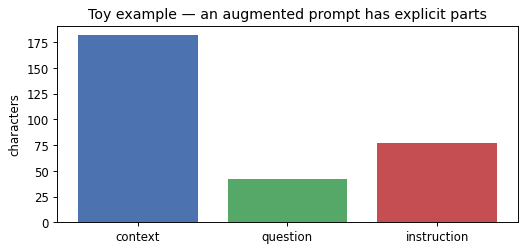

In [26]:
a_retrieved_chunks = [a_chunks[a_i] for a_i in a_topk]
a_context_block = "\n".join([f"[{a_chunk['chunk_id']}] {a_chunk['text']}" for a_chunk in a_retrieved_chunks])
a_instruction = "Answer using only the context. If the answer is missing, say you do not know."
a_prompt = "Context:\n" + a_context_block + "\n\nQuestion: " + a_user_question + "\n" + a_instruction

print("FULL AUGMENTED PROMPT START")
print(a_prompt)
print("FULL AUGMENTED PROMPT END")
print("Context characters:", len(a_context_block))
print("Question characters:", len(a_user_question))
print("Instruction characters:", len(a_instruction))

assert "Context:" in a_prompt and "Question:" in a_prompt and "C01" in a_prompt

a_prompt_parts = ["context", "question", "instruction"]
a_prompt_sizes = [len(a_context_block), len(a_user_question), len(a_instruction)]
plt.figure(figsize=(7, 3))
plt.bar(a_prompt_parts, a_prompt_sizes, color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("characters")
plt.title("Toy example — an augmented prompt has explicit parts")
plt.show()

▶ What you'll see: the generator would receive context, question, and instruction as separate pieces.

## Part A Step 9 · Toy example — generate, simulated and grounded

This notebook has **no real LLM**. The "generator" is a tiny extractive function: it returns an answer
built only from retrieved chunks. We also contrast it with a no-context guess.

**Good for:** reducing hallucination by forcing answers to come from evidence.  
**Watch out for:** a real LLM can still misread context; grounding lowers risk, not all errors.

Question: How many vacation days do interns receive?
No-context answer: No-context answer: interns might get 10 vacation days. (This is a guess.)
RAG grounded answer: Interns receive 5 vacation days during summer. [C01]
Evidence chunk used: C01 Interns receive 5 vacation days during summer.


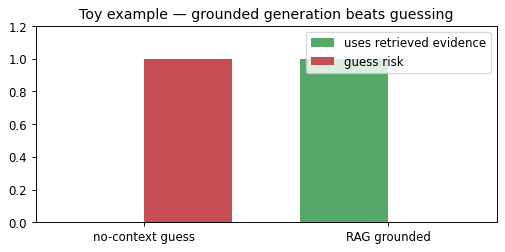

In [29]:
def a_simulated_grounded_answer(a_question_text, a_retrieved_list):
    a_best_chunk = a_retrieved_list[0]
    a_best_text = a_best_chunk["text"]
    if "vacation" in a_question_text.lower() and "intern" in a_question_text.lower():
        return f"Interns receive 5 vacation days during summer. [{a_best_chunk['chunk_id']}]"
    return f"{a_best_text} [{a_best_chunk['chunk_id']}]"

a_grounded_answer = a_simulated_grounded_answer(a_user_question, a_retrieved_chunks)
a_no_context_answer = "No-context answer: interns might get 10 vacation days. (This is a guess.)"

print("Question:", a_user_question)
print("No-context answer:", a_no_context_answer)
print("RAG grounded answer:", a_grounded_answer)
print("Evidence chunk used:", a_retrieved_chunks[0]["chunk_id"], a_retrieved_chunks[0]["text"])

assert "5 vacation days" in a_grounded_answer
assert "[C01]" in a_grounded_answer

a_answer_labels = ["no-context guess", "RAG grounded"]
a_grounded_score = [0, 1]
a_guess_risk = [1, 0]
a_ans_x = np.arange(len(a_answer_labels))
plt.figure(figsize=(7, 3))
plt.bar(a_ans_x - 0.18, a_grounded_score, width=0.36, label="uses retrieved evidence", color="#55A868")
plt.bar(a_ans_x + 0.18, a_guess_risk, width=0.36, label="guess risk", color="#C44E52")
plt.xticks(a_ans_x, a_answer_labels)
plt.ylim(0, 1.2)
plt.title("Toy example — grounded generation beats guessing")
plt.legend()
plt.show()

▶ What you'll see: the grounded answer cites C01 and repeats the retrieved fact.

## Part A Step 10 · Toy example — citations

A **citation** points back to the chunk used as evidence. A citation is not magic proof, but it makes the
answer inspectable.

Grounded answer: Interns receive 5 vacation days during summer. [C01]
Citation table:
 rank chunk_id           title  score                                                          text
    1      C01 Vacation policy  0.781                Interns receive 5 vacation days during summer.
    2      C00 Vacation policy  0.367       Full-time employees receive 15 vacation days each year.
    3      C07  Data retention  0.070 Customer analytics logs are kept for 30 days before deletion.


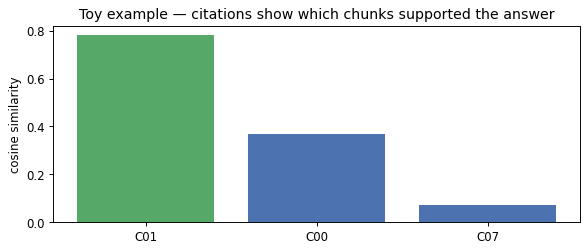

In [32]:
a_citation_rows = []
for a_rank, a_idx in enumerate(a_topk, 1):
    a_citation_rows.append({
        "rank": a_rank,
        "chunk_id": a_chunks[a_idx]["chunk_id"],
        "title": a_chunks[a_idx]["title"],
        "score": round(float(a_sims[a_idx]), 3),
        "text": a_chunks[a_idx]["text"],
    })
a_citations = pd.DataFrame(a_citation_rows)

print("Grounded answer:", a_grounded_answer)
print("Citation table:")
print(a_citations.to_string(index=False))

assert a_citations.iloc[0]["chunk_id"] == "C01"

plt.figure(figsize=(8, 3))
plt.bar(a_citations["chunk_id"], a_citations["score"], color=["#55A868", "#4C72B0", "#4C72B0"])
plt.ylabel("cosine similarity")
plt.title("Toy example — citations show which chunks supported the answer")
plt.show()

▶ What you'll see: C01 is the first citation because it had the best similarity.

## Part A Step 11 · Toy example — no-answer fallback

Sometimes the answer is not in the knowledge base. A safe RAG system should say **"I don't know"**
instead of hallucinating. We use a threshold: if the best similarity is too low, refuse to answer.

**Good for:** avoiding confident answers when retrieval finds weak evidence.  
**Watch out for:** threshold tuning is a product decision; too high rejects good questions, too low allows risky ones.

Off-topic query: What is the stock price tomorrow?
Query vector non-zero terms: 0
Similarity to every chunk: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Best similarity: 0.0
Threshold: 0.25
Answer: I don't know — that is not in my knowledge base.


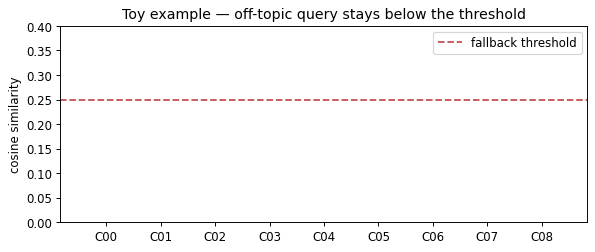

In [35]:
a_fallback_threshold = 0.25
a_off_topic_query = "What is the stock price tomorrow?"
a_off_q_vec, a_off_sims, a_off_topk, a_off_order = a_rank_chunks(a_off_topic_query, a_k=3)
a_off_max = float(a_off_sims[a_off_order[0]])

def a_answer_with_fallback(a_question_text, a_k=3, a_threshold=0.25):
    a_local_q, a_local_sims, a_local_topk, a_local_order = a_rank_chunks(a_question_text, a_k=a_k)
    a_best_score = float(a_local_sims[a_local_order[0]])
    if a_best_score < a_threshold:
        return "I don't know — that is not in my knowledge base.", a_local_sims, a_local_topk, a_local_order
    a_local_retrieved = [a_chunks[a_i] for a_i in a_local_topk]
    return a_simulated_grounded_answer(a_question_text, a_local_retrieved), a_local_sims, a_local_topk, a_local_order

a_fallback_answer, a_checked_sims, a_checked_topk, a_checked_order = a_answer_with_fallback(
    a_off_topic_query, a_threshold=a_fallback_threshold
)

print("Off-topic query:", a_off_topic_query)
print("Query vector non-zero terms:", int((a_off_q_vec > 0).sum()))
print("Similarity to every chunk:", np.round(a_off_sims, 3).tolist())
print("Best similarity:", round(a_off_max, 3))
print("Threshold:", a_fallback_threshold)
print("Answer:", a_fallback_answer)

assert a_off_max < a_fallback_threshold
assert a_fallback_answer.startswith("I don't know")

plt.figure(figsize=(8, 3))
plt.bar([a_chunk["chunk_id"] for a_chunk in a_chunks], a_off_sims, color="#BBBBBB")
plt.axhline(a_fallback_threshold, color="#C44E52", linestyle="--", label="fallback threshold")
plt.ylabel("cosine similarity")
plt.title("Toy example — off-topic query stays below the threshold")
plt.legend()
plt.ylim(0, a_fallback_threshold + 0.15)
plt.show()

▶ What you'll see: every similarity bar stays below the fallback line, so the answer is `I don't know`.

---
# Part B · Query understanding: parse, ground, score, route

## Part B Step 1 · Toy example — natural language → structured intent + slots

An **intent** is what the user wants, like `search_flights` or `search_products`.
A **slot** is a parameter value, like `destination = Tokyo`, `color = red`, or `size = 10`.

Production systems may ask an LLM for JSON. Here we use a small regex + keyword parser so it is fully
offline and every number is visible.

**Good for:** turning free text into API/database parameters.  
**Watch out for:** parsers guess; do not execute until important values are checked.

[query] cheap flights to tokyo next friday
[tokens] ['cheap', 'flights', 'friday', 'next', 'to', 'tokyo']
[flight keyword hits] 3
[product keyword hits] 0
[intent scores] {'search_flights': 0.8, 'search_products': 0.2}
[query] show me red running shoes under $80 size 10
[tokens] ['$', 'me', 'red', 'running', 'shoes', 'show', 'size', 'under']
[flight keyword hits] 0
[product keyword hits] 6
[intent scores] {'search_flights': 0.125, 'search_products': 0.875}
[slot extraction] destination <- Tokyo
[slot extraction] date <- next Friday
[slot extraction] price <- low
[slot extraction] category <- running shoes
[slot extraction] color <- red
[slot extraction] max_price <- 80
[slot extraction] size <- 10
[parsed flight dict] {'intent': 'search_flights', 'slots': {'destination': 'Tokyo', 'date': 'next Friday', 'price': 'low'}, 'intent_scores': {'search_flights': 0.8, 'search_products': 0.2}}
[parsed product dict] {'intent': 'search_products', 'slots': {'category': 'running shoes', 'color': 're

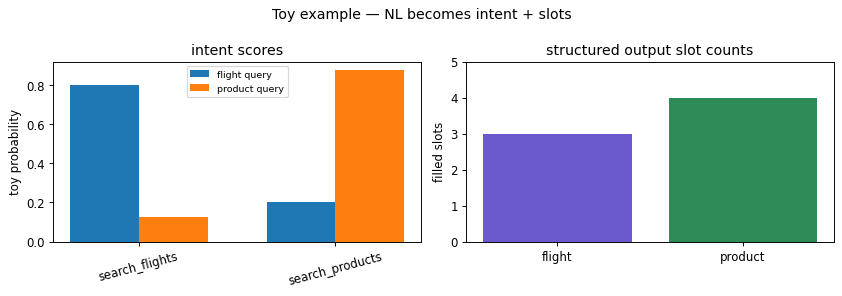

In [39]:
b_intents = ["search_flights", "search_products"]
b_flight_words = {"flight", "flights", "fly", "tokyo", "friday"}
b_product_words = {"shoes", "shoe", "running", "red", "size", "under", "$"}

def b_keyword_intent_scores(b_text):
    b_words = set(re.findall(r"[a-z$]+", b_text.lower()))
    b_flight_hits = len(b_words & b_flight_words)
    b_product_hits = len(b_words & b_product_words)
    b_raw = np.array([1 + b_flight_hits, 1 + b_product_hits], dtype=float)
    b_probs = b_raw / b_raw.sum()
    return dict(zip(b_intents, b_probs)), {"words": sorted(b_words), "flight_hits": b_flight_hits, "product_hits": b_product_hits}

def b_parse_query(b_text):
    b_scores, _ = b_keyword_intent_scores(b_text)
    b_intent = max(b_scores, key=b_scores.get)
    b_lower = b_text.lower()
    b_slots = {}

    if b_intent == "search_flights":
        b_dest = re.search(r"to\s+([a-z]+)", b_lower)
        if b_dest:
            b_slots["destination"] = b_dest.group(1).title()
            log("slot extraction", f"destination <- {b_slots['destination']}")
        if "next friday" in b_lower:
            b_slots["date"] = "next Friday"
            log("slot extraction", "date <- next Friday")
        if "cheap" in b_lower:
            b_slots["price"] = "low"
            log("slot extraction", "price <- low")

    if b_intent == "search_products":
        if "running shoes" in b_lower:
            b_slots["category"] = "running shoes"
            log("slot extraction", "category <- running shoes")
        for b_color in ["red", "blue", "black", "white", "crimson", "turquoise"]:
            if b_color in b_lower:
                b_slots["color"] = b_color
                log("slot extraction", f"color <- {b_color}")
                break
        b_price = re.search(r"under\s*\$?(\d+)", b_lower)
        if b_price:
            b_slots["max_price"] = int(b_price.group(1))
            log("slot extraction", f"max_price <- {b_slots['max_price']}")
        b_size = re.search(r"size\s*(\d+)", b_lower)
        if b_size:
            b_slots["size"] = int(b_size.group(1))
            log("slot extraction", f"size <- {b_slots['size']}")

    return {"intent": b_intent, "slots": b_slots, "intent_scores": b_scores}

b_flight_text = "cheap flights to tokyo next friday"
b_product_text = "show me red running shoes under $80 size 10"
b_all_intent_scores = []
for b_query_text in [b_flight_text, b_product_text]:
    b_scores, b_details = b_keyword_intent_scores(b_query_text)
    b_all_intent_scores.append(b_scores)
    log("query", b_query_text)
    log("tokens", b_details["words"])
    log("flight keyword hits", b_details["flight_hits"])
    log("product keyword hits", b_details["product_hits"])
    log("intent scores", {b_key: round(b_val, 3) for b_key, b_val in b_scores.items()})

b_flight_parse = b_parse_query(b_flight_text)
b_product_parse = b_parse_query(b_product_text)
b_expected_flight = {"intent": "search_flights", "slots": {"destination": "Tokyo", "date": "next Friday", "price": "low"}}
b_expected_product = {"intent": "search_products", "slots": {"category": "running shoes", "color": "red", "max_price": 80, "size": 10}}
log("parsed flight dict", b_flight_parse)
log("parsed product dict", b_product_parse)
assert {"intent": b_flight_parse["intent"], "slots": b_flight_parse["slots"]} == b_expected_flight
assert {"intent": b_product_parse["intent"], "slots": b_product_parse["slots"]} == b_expected_product

b_slot_counts = [len(b_flight_parse["slots"]), len(b_product_parse["slots"])]
b_intent_x = np.arange(len(b_intents))
fig, b_axes = plt.subplots(1, 2, figsize=(10, 3.5))
b_width = 0.35
b_axes[0].bar(b_intent_x - b_width/2, [b_all_intent_scores[0][b_i] for b_i in b_intents], b_width, label="flight query")
b_axes[0].bar(b_intent_x + b_width/2, [b_all_intent_scores[1][b_i] for b_i in b_intents], b_width, label="product query")
b_axes[0].set_xticks(b_intent_x, b_intents, rotation=15)
b_axes[0].set_ylabel("toy probability")
b_axes[0].set_title("intent scores")
b_axes[0].legend(fontsize=8)
b_axes[1].bar(["flight", "product"], b_slot_counts, color=["slateblue", "seagreen"])
b_axes[1].set_ylabel("filled slots")
b_axes[1].set_ylim(0, 5)
b_axes[1].set_title("structured output slot counts")
plt.suptitle("Toy example — NL becomes intent + slots")
plt.tight_layout()
plt.show()

▶ What you'll see: the flight query fills destination/date/price; the product query fills category/color/price/size.

## Part B Step 2 · Toy example — retrieval-grounded interpretation

**Grounding** means checking a parsed value against trusted data. A parser might output `crimson`, but the
real catalog might only allow `[red, blue, black, white]`.

Accept threshold = `0.5`:
- `red` → accept with score `1.00`
- `crimson` → reject with score about `0.20`
- `turquoise` → reject with score about `0.20`

**Good for:** catching unsupported slot values before execution.  
**Watch out for:** thresholds change behavior; tune them on real data.

[input color] red
[candidate scores] {'red': 1.0, 'blue': 0.2, 'black': 0.2, 'white': 0.2}
[nearest + decision] red (match 1.00) -> ACCEPT
[input color] crimson
[candidate scores] {'red': 0.2, 'blue': 0.2, 'black': 0.2, 'white': 0.2}
[nearest + decision] red (match 0.20) -> REJECT
[input color] turquoise
[candidate scores] {'red': 0.2, 'blue': 0.2, 'black': 0.2, 'white': 0.2}
[nearest + decision] red (match 0.20) -> REJECT


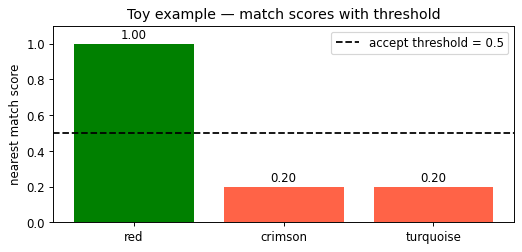

In [42]:
b_valid_colors = ["red", "blue", "black", "white"]
b_accept_threshold = 0.5

def b_toy_similarity(b_user_value, b_catalog_value):
    b_u = b_user_value.lower()
    b_c = b_catalog_value.lower()
    if b_u == b_c:
        return 1.0
    if b_u in b_c or b_c in b_u:
        return 0.6
    return 0.2

def b_nearest_catalog_value(b_user_value, b_catalog):
    b_scores = [b_toy_similarity(b_user_value, b_candidate) for b_candidate in b_catalog]
    b_best_i = int(np.argmax(b_scores))
    return b_catalog[b_best_i], b_scores[b_best_i], dict(zip(b_catalog, b_scores))

b_color_inputs = ["red", "crimson", "turquoise"]
b_grounding_rows = []
for b_color in b_color_inputs:
    b_nearest, b_score, b_score_dict = b_nearest_catalog_value(b_color, b_valid_colors)
    b_accepted = b_score >= b_accept_threshold
    b_grounding_rows.append({"input": b_color, "nearest": b_nearest, "score": b_score, "accepted": b_accepted})
    log("input color", b_color)
    log("candidate scores", b_score_dict)
    log("nearest + decision", f"{b_nearest} (match {b_score:.2f}) -> {'ACCEPT' if b_accepted else 'REJECT'}")

b_grounding_df = pd.DataFrame(b_grounding_rows)
b_red_row = b_grounding_df.loc[b_grounding_df.input == "red"].iloc[0]
b_crimson_row = b_grounding_df.loc[b_grounding_df.input == "crimson"].iloc[0]
b_turquoise_row = b_grounding_df.loc[b_grounding_df.input == "turquoise"].iloc[0]
assert bool(b_red_row["accepted"]) and round(float(b_red_row["score"]), 2) == 1.00
assert not bool(b_crimson_row["accepted"]) and round(float(b_crimson_row["score"]), 2) == 0.20
assert not bool(b_turquoise_row["accepted"]) and round(float(b_turquoise_row["score"]), 2) == 0.20

plt.figure(figsize=(7, 3))
plt.bar(b_grounding_df["input"], b_grounding_df["score"],
        color=["green" if b_ok else "tomato" for b_ok in b_grounding_df["accepted"]])
plt.axhline(b_accept_threshold, color="black", linestyle="--", label="accept threshold = 0.5")
for b_i, b_row in b_grounding_df.iterrows():
    plt.text(b_i, b_row["score"] + 0.03, f"{b_row['score']:.2f}", ha="center")
plt.ylabel("nearest match score")
plt.ylim(0, 1.1)
plt.title("Toy example — match scores with threshold")
plt.legend()
plt.show()

▶ What you'll see: only `red` crosses the 0.5 accept line.

## Part B Step 3 · Toy example — confidence as a weighted average

**Confidence** is a score for how trustworthy the whole parse is. We combine four measurable signals:
`slot_fill_rate`, `ground_match`, `intent_prob`, and `retrieval_sim`.

$\text{confidence} = \sum_i w_i s_i = 0.25s_1 + 0.30s_2 + 0.25s_3 + 0.20s_4$

**Good for:** routing based on multiple behavioral signals.  
**Watch out for:** these weights are teaching weights, not production truth.

[case] clear red shoes size 10
[signals] {'slot_fill_rate': 1.0, 'ground_match': 1.0, 'intent_prob': 0.95, 'retrieval_sim': 0.9}
[weighted contributions] {'slot_fill_rate': 0.25, 'ground_match': 0.3, 'intent_prob': 0.238, 'retrieval_sim': 0.18}
[final confidence] 0.9675
[case] vague something nice
[signals] {'slot_fill_rate': 0.2, 'ground_match': 0.3, 'intent_prob': 0.4, 'retrieval_sim': 0.35}
[weighted contributions] {'slot_fill_rate': 0.05, 'ground_match': 0.09, 'intent_prob': 0.1, 'retrieval_sim': 0.07}
[final confidence] 0.31
[case] typo flights to tokoyo
[signals] {'slot_fill_rate': 0.8, 'ground_match': 0.7, 'intent_prob': 0.85, 'retrieval_sim': 0.6}
[weighted contributions] {'slot_fill_rate': 0.2, 'ground_match': 0.21, 'intent_prob': 0.212, 'retrieval_sim': 0.12}
[final confidence] 0.7425
Rounded confidences: {'clear red shoes size 10': 0.97, 'vague something nice': 0.31, 'typo flights to tokoyo': 0.74}


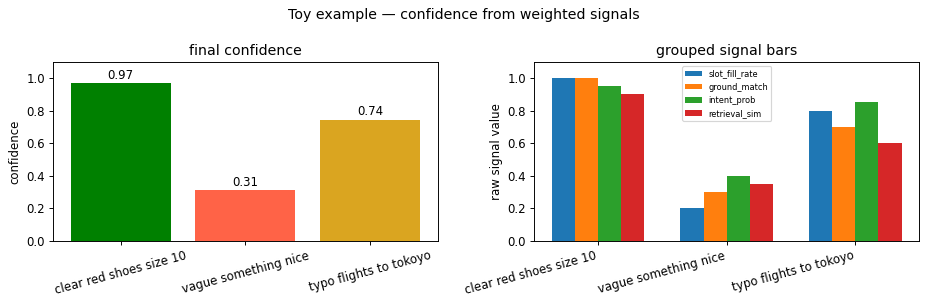

In [45]:
b_signal_names = ["slot_fill_rate", "ground_match", "intent_prob", "retrieval_sim"]
b_weights = np.array([0.25, 0.30, 0.25, 0.20])
b_confidence_cases = {
    "clear red shoes size 10": np.array([1.0, 1.0, 0.95, 0.90]),
    "vague something nice": np.array([0.2, 0.3, 0.40, 0.35]),
    "typo flights to tokoyo": np.array([0.8, 0.7, 0.85, 0.60]),
}
b_expected_confidences = {
    "clear red shoes size 10": 0.97,
    "vague something nice": 0.31,
    "typo flights to tokoyo": 0.74,
}

def b_confidence(b_signals):
    return float(np.sum(b_weights * b_signals))

b_conf_rows = []
b_contrib_rows = []
for b_case_name, b_signals in b_confidence_cases.items():
    b_contributions = b_weights * b_signals
    b_conf = b_confidence(b_signals)
    b_conf_rows.append({"case": b_case_name, "confidence": b_conf})
    b_contrib_rows.append(b_contributions)
    log("case", b_case_name)
    log("signals", dict(zip(b_signal_names, np.round(b_signals, 3))))
    log("weighted contributions", dict(zip(b_signal_names, np.round(b_contributions, 3))))
    log("final confidence", round(b_conf, 4))
    assert round(b_conf, 2) == b_expected_confidences[b_case_name]

b_conf_df = pd.DataFrame(b_conf_rows)
b_case_names = list(b_confidence_cases.keys())
b_signal_matrix = np.vstack([b_confidence_cases[b_case] for b_case in b_case_names])

print("Rounded confidences:", {b_case: round(b_confidence(b_confidence_cases[b_case]), 2) for b_case in b_case_names})

fig, b_conf_axes = plt.subplots(1, 2, figsize=(11, 3.6))
b_conf_axes[0].bar(b_conf_df["case"], b_conf_df["confidence"], color=["green", "tomato", "goldenrod"])
for b_i, b_row in b_conf_df.iterrows():
    b_conf_axes[0].text(b_i, b_row["confidence"] + 0.03, f"{b_row['confidence']:.2f}", ha="center")
b_conf_axes[0].set_ylim(0, 1.1)
b_conf_axes[0].set_ylabel("confidence")
b_conf_axes[0].set_title("final confidence")
b_conf_axes[0].tick_params(axis="x", rotation=15)

b_group_x = np.arange(len(b_case_names))
b_group_width = 0.18
for b_j, b_signal_name in enumerate(b_signal_names):
    b_conf_axes[1].bar(b_group_x + (b_j - 1.5) * b_group_width, b_signal_matrix[:, b_j], b_group_width, label=b_signal_name)
b_conf_axes[1].set_xticks(b_group_x, b_case_names, rotation=15, ha="right")
b_conf_axes[1].set_ylim(0, 1.1)
b_conf_axes[1].set_ylabel("raw signal value")
b_conf_axes[1].set_title("grouped signal bars")
b_conf_axes[1].legend(fontsize=7)
plt.suptitle("Toy example — confidence from weighted signals")
plt.tight_layout()
plt.show()

▶ What you'll see: clear = 0.97, vague = 0.31, typo = 0.74.

## Part B Step 4 · Toy example — low-confidence fallback router

A **fallback** is the safe behavior when confidence is too low, such as keyword search or a clarifying
question.

Routing rule:
- `conf >= HIGH` (`0.75`) → **EXECUTE**
- `LOW <= conf < HIGH` (`0.45` to `0.75`) → **CONFIRM/CLARIFY**
- `conf < LOW` → **FALLBACK**

**Good for:** preventing a wrong parse from silently running.  
**Watch out for:** bad thresholds can either block too much or execute risky parses.

[routing decision] clear red shoes size 10: confidence=0.97 -> EXECUTE
[routing decision] vague something nice: confidence=0.31 -> FALLBACK
[routing decision] typo flights to tokoyo: confidence=0.74 -> CONFIRM


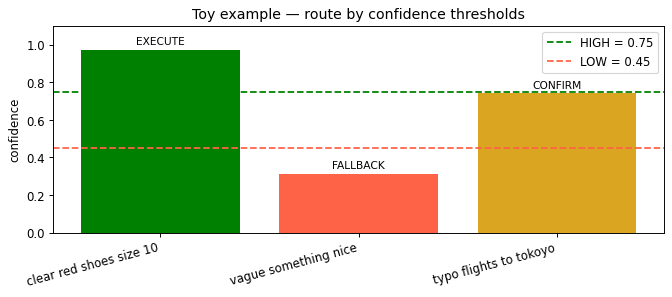

In [48]:
b_HIGH = 0.75
b_LOW = 0.45

def b_route(b_conf):
    if b_conf >= b_HIGH:
        return "EXECUTE"
    if b_conf >= b_LOW:
        return "CONFIRM"
    return "FALLBACK"

b_routes = {}
for b_case_name in b_case_names:
    b_rounded_conf = b_expected_confidences[b_case_name]
    b_routes[b_case_name] = b_route(b_rounded_conf)
    log("routing decision", f"{b_case_name}: confidence={b_rounded_conf:.2f} -> {b_routes[b_case_name]}")

assert b_routes["clear red shoes size 10"] == "EXECUTE"
assert b_routes["typo flights to tokoyo"] == "CONFIRM"
assert b_routes["vague something nice"] == "FALLBACK"

b_behavioral = np.array([b_expected_confidences[b_case_name] for b_case_name in b_case_names])
b_route_colors = {"EXECUTE": "green", "CONFIRM": "goldenrod", "FALLBACK": "tomato"}
plt.figure(figsize=(8, 3.6))
plt.bar(b_case_names, b_behavioral, color=[b_route_colors[b_routes[b_case_name]] for b_case_name in b_case_names])
plt.axhline(b_HIGH, color="green", linestyle="--", label="HIGH = 0.75")
plt.axhline(b_LOW, color="tomato", linestyle="--", label="LOW = 0.45")
for b_i, b_case_name in enumerate(b_case_names):
    plt.text(b_i, b_behavioral[b_i] + 0.03, b_routes[b_case_name], ha="center", fontsize=9)
plt.ylim(0, 1.1)
plt.ylabel("confidence")
plt.xticks(rotation=15, ha="right")
plt.title("Toy example — route by confidence thresholds")
plt.legend()
plt.tight_layout()
plt.show()

▶ What you'll see: 0.97 executes, 0.74 asks for confirmation, and 0.31 falls back.

## Part B Step 5 · Toy example — pipeline pseudocode and RAG handoff

Plain-English pseudocode:

1. **parse** natural language into `{intent, slots}`.
2. **ground** each important slot against trusted data.
3. **score** confidence from behavioral signals.
4. **route**: execute, confirm/clarify, or fallback.
5. If trustworthy, the structured query can feed **Part A's RAG retrieval** as a cleaner, grounded search.

[pipeline input] show me red running shoes under $80 size 10
[slot extraction] category <- running shoes
[slot extraction] color <- red
[slot extraction] max_price <- 80
[slot extraction] size <- 10
[1 parse] {'intent': 'search_products', 'slots': {'category': 'running shoes', 'color': 'red', 'max_price': 80, 'size': 10}}
[ground_color_slot] {'raw': 'red', 'nearest': 'red', 'score': 1.0, 'accepted': True}
[2 color grounding] {'raw': 'red', 'nearest': 'red', 'score': 1.0, 'accepted': True}
[3 confidence] 0.9675
[4 route] EXECUTE
[pipeline input] cheap flights to tokoyo next friday
[slot extraction] destination <- Tokoyo
[slot extraction] date <- next Friday
[slot extraction] price <- low
[1 parse] {'intent': 'search_flights', 'slots': {'destination': 'Tokoyo', 'date': 'next Friday', 'price': 'low'}}
[2 color grounding] no color slot to ground
[3 confidence] 0.7425
[4 route] CONFIRM
[pipeline input] something nice
[1 parse] {'intent': 'search_flights', 'slots': {}}
[2 color grounding] no

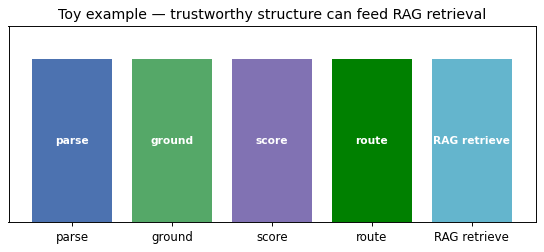

In [51]:
def b_ground_color_slot(b_raw_color):
    b_nearest, b_score, _ = b_nearest_catalog_value(b_raw_color, b_valid_colors)
    b_accepted = b_score >= b_accept_threshold
    b_result = {"raw": b_raw_color, "nearest": b_nearest, "score": b_score, "accepted": b_accepted}
    log("ground_color_slot", b_result)
    return b_result

def b_run_understanding_pipeline(b_query_text, b_signals):
    log("pipeline input", b_query_text)
    b_parsed = b_parse_query(b_query_text)
    log("1 parse", {"intent": b_parsed["intent"], "slots": b_parsed["slots"]})
    b_grounded_slots = b_parsed["slots"].copy()
    if "color" in b_grounded_slots:
        b_grounding = b_ground_color_slot(b_grounded_slots["color"])
        b_grounded_slots["color"] = b_grounding["nearest"] if b_grounding["accepted"] else None
        log("2 color grounding", b_grounding)
    else:
        log("2 color grounding", "no color slot to ground")
    b_conf = b_confidence(b_signals)
    b_r = b_route(round(b_conf, 2))
    log("3 confidence", round(b_conf, 4))
    log("4 route", b_r)
    return {"query": b_query_text, "parsed": b_parsed, "grounded_slots": b_grounded_slots, "confidence": b_conf, "route": b_r}

b_pipeline_examples = [
    (b_product_text, b_confidence_cases["clear red shoes size 10"]),
    ("cheap flights to tokoyo next friday", b_confidence_cases["typo flights to tokoyo"]),
    ("something nice", b_confidence_cases["vague something nice"]),
]
b_pipeline_results = [b_run_understanding_pipeline(b_query_text, b_signals) for b_query_text, b_signals in b_pipeline_examples]

print("Pipeline routes:", [b_result["route"] for b_result in b_pipeline_results])

assert [b_result["route"] for b_result in b_pipeline_results] == ["EXECUTE", "CONFIRM", "FALLBACK"]

b_trusted = b_pipeline_results[0]
b_clean_search = " ".join([
    b_trusted["grounded_slots"].get("category", ""),
    b_trusted["grounded_slots"].get("color", ""),
    "size",
    str(b_trusted["grounded_slots"].get("size", "")),
    "under",
    str(b_trusted["grounded_slots"].get("max_price", "")),
]).strip()
log("trusted route", b_trusted["route"])
log("clean grounded search string for a retriever", b_clean_search)
assert b_trusted["route"] == "EXECUTE"
assert "red" in b_clean_search and "10" in b_clean_search

plt.figure(figsize=(8, 3))
plt.bar(["parse", "ground", "score", "route", "RAG retrieve"], [1, 1, 1, 1, 1],
        color=["#4C72B0", "#55A868", "#8172B3", b_route_colors[b_trusted["route"]], "#64B5CD"])
for b_i, b_label in enumerate(["parse", "ground", "score", "route", "RAG retrieve"]):
    plt.text(b_i, 0.5, b_label, ha="center", va="center", color="white", weight="bold", fontsize=9)
plt.ylim(0, 1.2)
plt.yticks([])
plt.title("Toy example — trustworthy structure can feed RAG retrieval")
plt.show()

▶ What you'll see: parse → ground → score → route runs before retrieval gets trusted parameters.

## Final toy example — sanity checks

Before shipping, pin the invariants: top-1 retrieval, fallback, grounding decisions, confidence values,
and routes.

[Part A top-1 retrieval is C01] True
[Part A no-answer fallback fires] True
[flight parse exact] True
[product parse exact] True
[red accepted 1.00] True
[crimson rejected 0.20] True
[turquoise rejected 0.20] True
[clear confidence 0.97] True
[vague confidence 0.31] True
[typo confidence 0.74] True
[routes pinned] True
[passed checks] 11 / 11


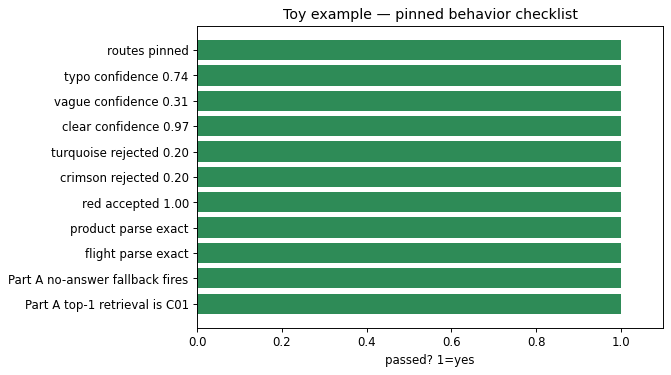

In [54]:
b_final_checks = {
    "Part A top-1 retrieval is C01": a_chunks[a_order[0]]["chunk_id"] == "C01",
    "Part A no-answer fallback fires": a_fallback_answer.startswith("I don't know"),
    "flight parse exact": {"intent": b_flight_parse["intent"], "slots": b_flight_parse["slots"]} == b_expected_flight,
    "product parse exact": {"intent": b_product_parse["intent"], "slots": b_product_parse["slots"]} == b_expected_product,
    "red accepted 1.00": bool(b_red_row["accepted"]) and round(float(b_red_row["score"]), 2) == 1.00,
    "crimson rejected 0.20": (not bool(b_crimson_row["accepted"])) and round(float(b_crimson_row["score"]), 2) == 0.20,
    "turquoise rejected 0.20": (not bool(b_turquoise_row["accepted"])) and round(float(b_turquoise_row["score"]), 2) == 0.20,
    "clear confidence 0.97": b_expected_confidences["clear red shoes size 10"] == 0.97,
    "vague confidence 0.31": b_expected_confidences["vague something nice"] == 0.31,
    "typo confidence 0.74": b_expected_confidences["typo flights to tokoyo"] == 0.74,
    "routes pinned": (
        b_routes["clear red shoes size 10"] == "EXECUTE"
        and b_routes["typo flights to tokoyo"] == "CONFIRM"
        and b_routes["vague something nice"] == "FALLBACK"
    ),
}
for b_label, b_ok in b_final_checks.items():
    log(b_label, b_ok)
assert all(b_final_checks.values())
log("passed checks", f"{sum(b_final_checks.values())} / {len(b_final_checks)}")

plt.figure(figsize=(8, 4.5))
plt.barh(list(b_final_checks.keys()), [int(b_ok) for b_ok in b_final_checks.values()], color="seagreen")
plt.xlim(0, 1.1)
plt.xlabel("passed? 1=yes")
plt.title("Toy example — pinned behavior checklist")
plt.tight_layout()
plt.show()

## Recap — M19 as one chain

The whole module is one safety chain:

**Understand the query**: parse → ground → score → route.  
**Retrieve grounded context**: chunk → embed → retrieve → augment → generate.

Two takeaways:
1. **Ground before you answer.** RAG grounds answers in retrieved chunks; query understanding grounds slots in trusted data.
2. **Fallback when evidence is weak.** Low retrieval similarity says "I don't know"; low query confidence asks for confirmation or falls back.